# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [209]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

%matplotlib inline

In [210]:
%load_ext autoreload
%autoreload 2

# Add the source path to Python path
src_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Base

In [3]:
source = 'base'

In [4]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

#### LC Collection Object

In [258]:
lccollection = VNeoMethodCollection()

In [259]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/data/methods/LC/Trap')

## MS Methods

### Load MS Methods

In [7]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [8]:
mscollection.add_methods_from_folder(f"{base}MethodOpt/LCMSmethodAnalysis/data/methods/MS/msmethods_260311.zip")
msmethod_names = '\n'.join(mscollection.methods.keys())

### BPS

In [12]:
# bpscollection = DiannCollection(log_file = f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/log/trapbpscollection.log')

In [10]:
# bpscollection.add_searches(f'{base}MethodOpt/LCMSmethodAnalysis/data/BPS/hela_bps_trap_260311_11am.zip',
#                             search_type='bps',
#                             levels=['precursor'])

In [30]:
# bpscollection.save(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [9]:
bpscollection = DiannCollection.from_file(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [ ]:
# map_lcms_methods(bpscollection, f'{base}MethodOpt/LCMSmethodAnalysis/data/sequences/2026_03.csv')

In [11]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


## Adjusted LC Meth

In [260]:
lccollection.bulk_adjust_gradients(bpscollection)

In [138]:
# lccollection.adjusted_methods['ML25p5FR200V9A15TrapNS5']['HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_FR200V9A15TrapNS5_DIA50ms122_TT0000475_R-H1_1_14985'].gradient

In [261]:
sample_subset = bpscollection['precursor'].var
sample_subset = sample_subset[sample_subset['hystar_index'].isin(['14987',
                                                                  '14970',
                                                                  '14971',
                                                                  '14969'])]

(<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Neo.PumpModule.Pump.Flow.Nominal [µl/min]'>,
 <Axes: ylabel='Neo.PumpModule.Pump.%B.Value [%]'>,
 <Axes: ylabel='Neo.PumpModule.Pump.Curve'>)

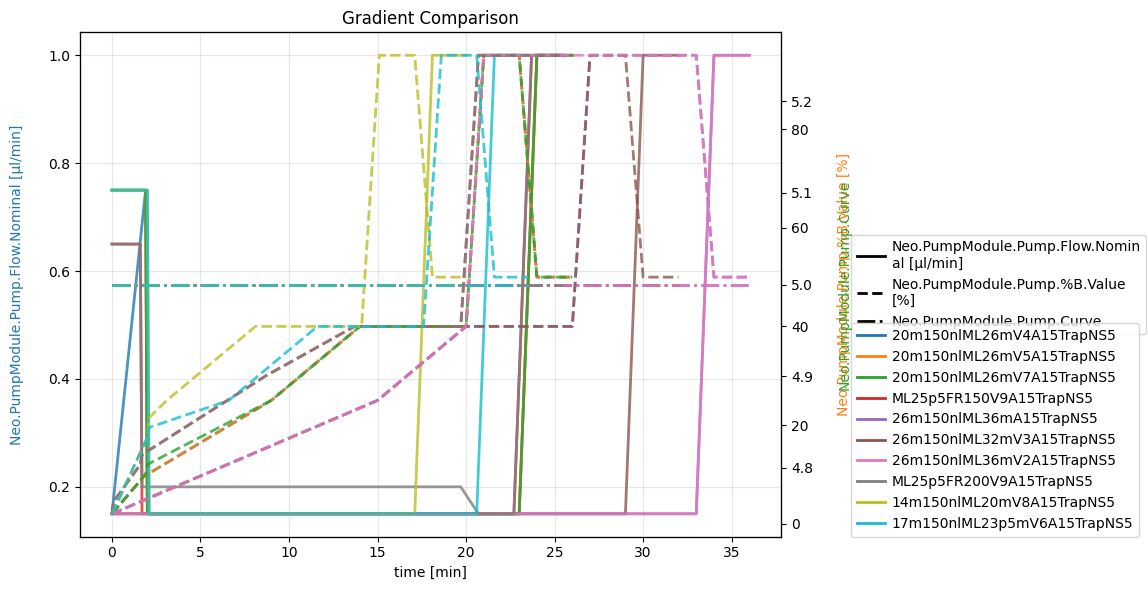

In [262]:
lccollection.plot_gradients(y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
                                        'Neo.PumpModule.Pump.%B.Value [%]','Neo.PumpModule.Pump.Curve'],
                                        twin_axes=True) 

In [281]:
test = bpscollection['precursor'][:, sample_subset['File.Name']]

In [ ]:
test

HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26minv32mML_DIA003_TT0000459_R-H1_1_14969


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

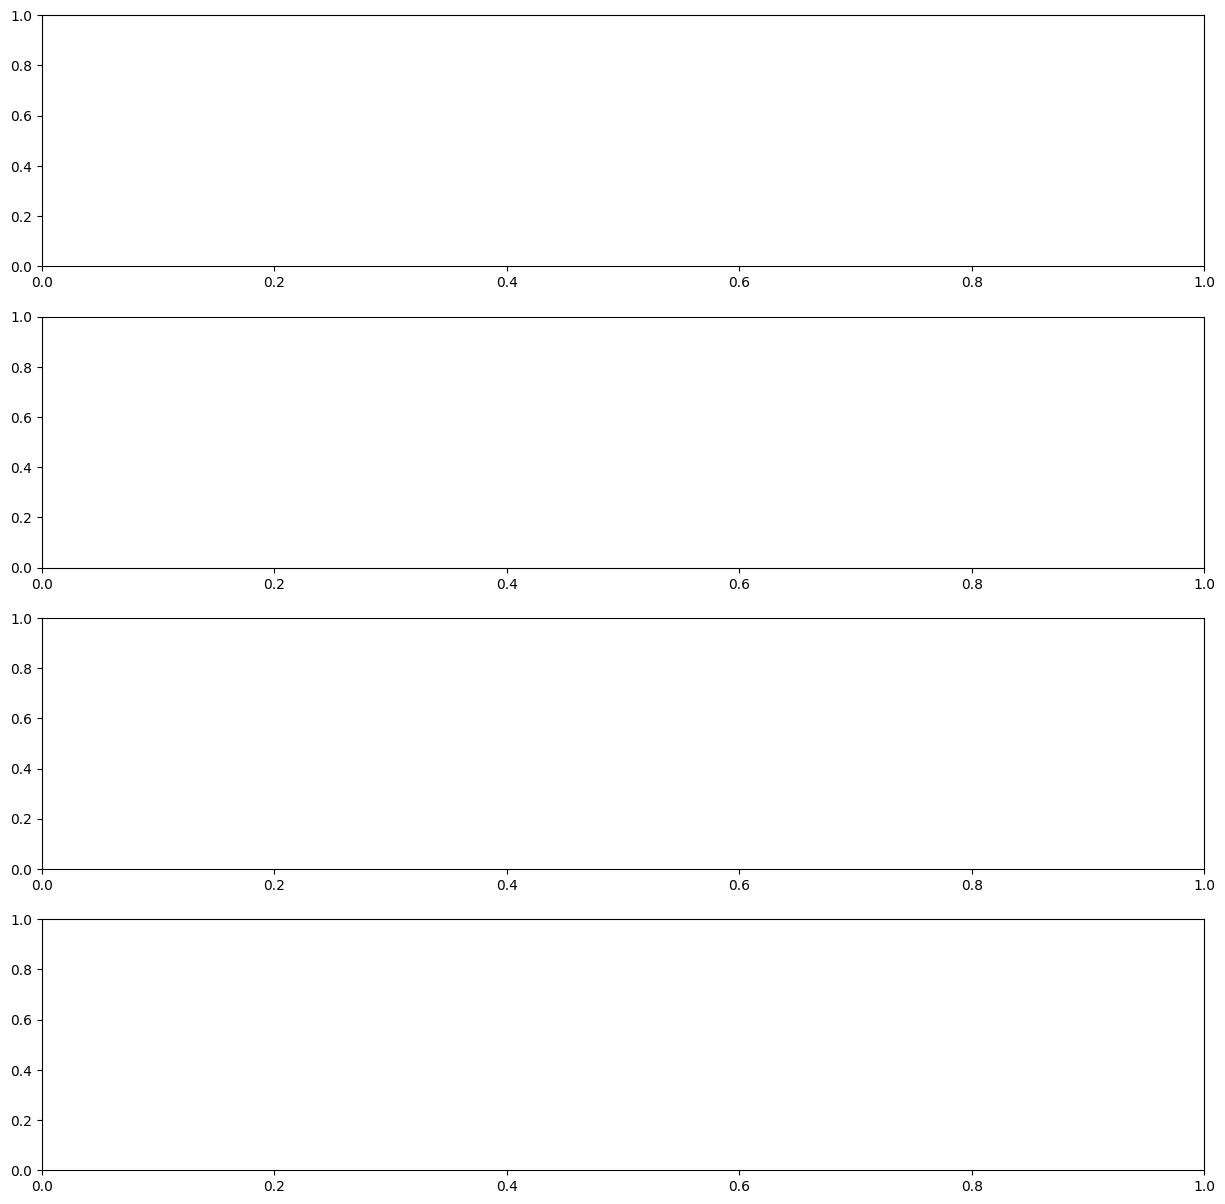

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15), nrows=4)

for i, name in enumerate(test.var_names):
    print(i)
    sns.histplot(x = test[:, name].layers['RT'].flatten(), ax=ax[i])
    lccollection.plot_gradients(sample_var = sample_subset,
                                x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                                y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'],
                                ax=ax[i])

<Axes: title={'center': 'Gradient Comparison'}, xlabel='X Value', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

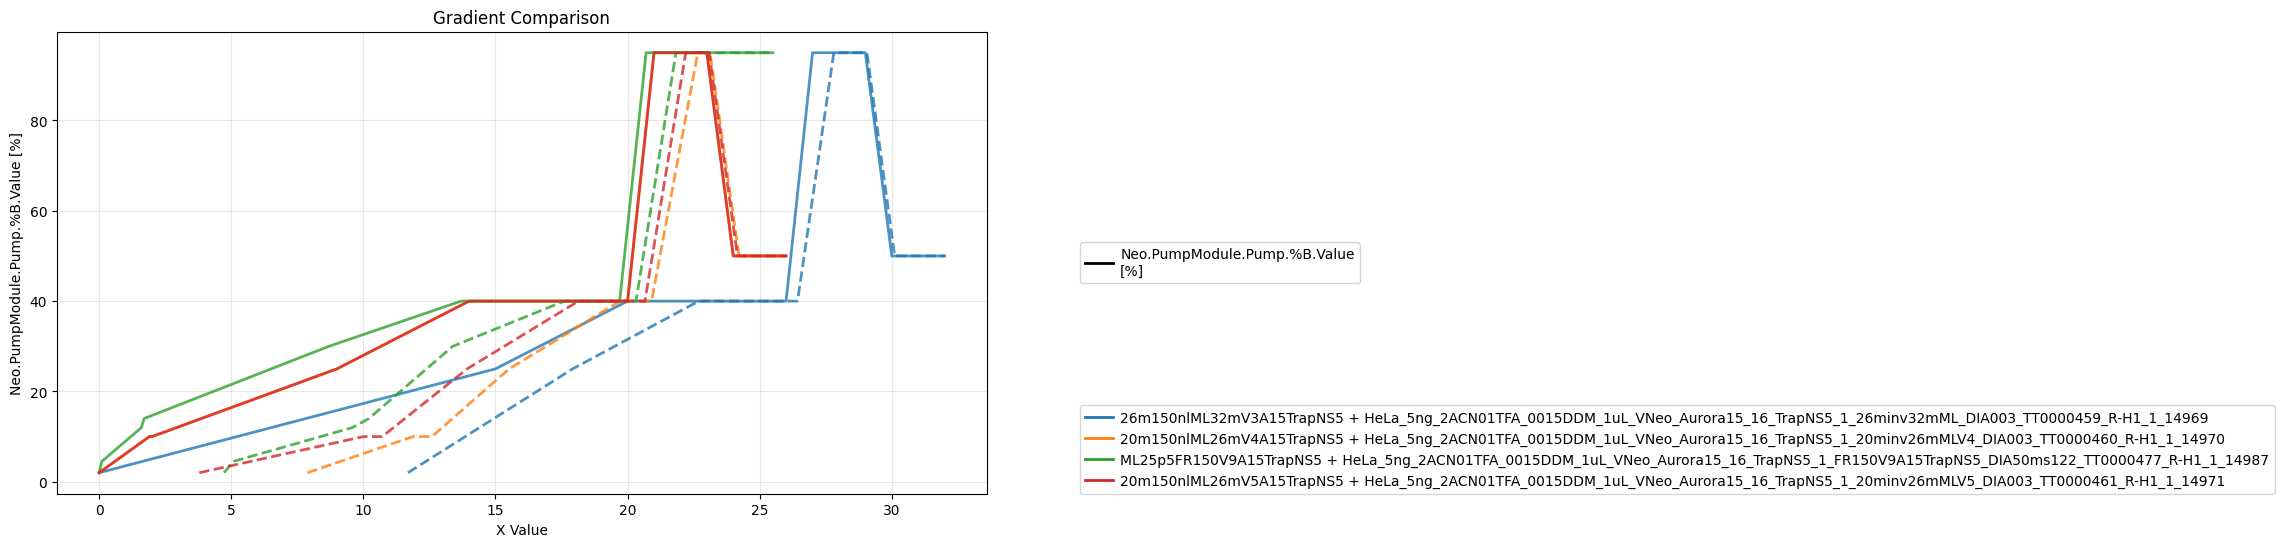

In [270]:
lccollection.plot_gradients(sample_var = sample_subset,
                            x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                            y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'])

### Plotting/Analysis

#### Checkign distribution of Values

In [29]:
def check_dist(ad, layer, samples=None, figsize=(10,6)):
    fig, ax = plt.subplots(figsize=figsize)
    df = ad.to_df(layer)
    if samples:
        df = df.loc[:, samples]

    df = df.melt(value_name=layer)

    for s in df.columns:
        sns.violinplot(data = df, x = 'File.Name', y = layer, ax=ax)
    
    plt.xticks(rotation=90)

## Compute CV

In [12]:
test = bpscollection['precursor'][:, bpscollection['precursor'].var['ms meth'].isin(['DIA003', 'DIA011RT75expandedrangeW83'])]

In [13]:
test2 = test[:, test.var['hystar_index'].astype(int) > 14701]

In [14]:
test2.var['File.Name'] = test2.var.index

/tmp/ipykernel_3371188/3159618787.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  test2.var['File.Name'] = test2.var.index


In [19]:
test2.var['input'] = test2.var['File.Name'].str.extract(r'HeLa_(\d+[np]g)_')

In [20]:
test2.layers['RTDiff'] = test2.layers['RT.Stop'] - test2.layers['RT.Start']

In [34]:
sample = 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA75msW83_TT0000314_B-B2_1_14717'

In [201]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Extract data arrays
mz_data = test2[:, sample].layers['Precursor.Calibrated.Mz'].astype(float).flatten()
k0_data = test2[:, sample].layers['Exp.1/K0'].astype(float).flatten()
quantity_data = test2[:, sample].layers['Precursor.Quantity'].astype(float).flatten()

# Calculate log2 intensities and handle invalid values
log2_quantity = np.log2(np.where(quantity_data > 0, quantity_data, np.nan))

# Create intensity bins/ranges for toggles
valid_mask = np.isfinite(log2_quantity) & np.isfinite(mz_data) & np.isfinite(k0_data)
valid_log2 = log2_quantity[valid_mask]

if len(valid_log2) > 0:
    # Define intensity ranges using percentiles
    percentiles = [0, 20, 40, 60, 80, 100]
    bin_edges = np.percentile(valid_log2, percentiles)
    bin_labels = [f'Very Low ({bin_edges[0]:.1f} - {bin_edges[1]:.1f})',
                  f'Low ({bin_edges[1]:.1f} - {bin_edges[2]:.1f})', 
                  f'Medium ({bin_edges[2]:.1f} - {bin_edges[3]:.1f})',
                  f'High ({bin_edges[3]:.1f} - {bin_edges[4]:.1f})',
                  f'Very High ({bin_edges[4]:.1f} - {bin_edges[5]:.1f})']
    
    # Assign bins to all data points
    intensity_bins = np.full(len(log2_quantity), 'No Signal')
    for i in range(len(bin_edges)-1):
        if i == 0:
            mask = (log2_quantity >= bin_edges[i]) & (log2_quantity <= bin_edges[i+1])
        else:
            mask = (log2_quantity > bin_edges[i]) & (log2_quantity <= bin_edges[i+1])
        intensity_bins[mask] = bin_labels[i]
    
    # Create DataFrame for Plotly
    df_plot = pd.DataFrame({
        'mz': mz_data,
        'k0': k0_data,
        'log2_quantity': log2_quantity,
        'intensity_bin': intensity_bins
    })
    
    # Remove invalid data
    df_plot = df_plot[valid_mask]
    
    # Create interactive scatter plot with toggles
    fig = px.scatter(df_plot, 
                     x='mz', 
                     y='k0',
                     color='log2_quantity',
                     color_continuous_scale='icefire',
                     opacity=0.6,
                     hover_data=['intensity_bin'],
                     labels={
                         'mz': 'Precursor m/z',
                         'k0': 'Experimental 1/K0', 
                         'log2_quantity': 'Log2(Intensity)',
                         'intensity_bin': 'Intensity Range'
                     },
                     title=f'Precursor Distribution - {sample}')
    
    # Set y-axis limits to match original plot
    fig.update_yaxes(range=[0.65, 1.45])
    
    # Add dropdown menu for intensity range selection
    buttons = []
    
    # Add "All" button
    buttons.append(dict(
        label="All Ranges",
        method="restyle",
        args=[{"visible": [True] * len(df_plot)}]
    ))
    
    # Add buttons for each intensity range
    for bin_label in bin_labels:
        visible_mask = df_plot['intensity_bin'] == bin_label
        buttons.append(dict(
            label=bin_label,
            method="restyle", 
            args=[{"visible": visible_mask.tolist()}]
        ))
    
    # Update layout with dropdown
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                y=1.0,
                xanchor="left",
                yanchor="top"
            )
        ],
        width=900,
        height=600,
        margin=dict(r=200)  # Make room for dropdown
    )
        
    print(f"Created interactive plot with {len(df_plot)} precursors")
    print(f"Intensity ranges (Log2):")
    for label in bin_labels:
        count = (df_plot['intensity_bin'] == label).sum()
        print(f"  {label}: {count} precursors")
else:
    print("No valid data found for plotting")

Created interactive plot with 84744 precursors
Intensity ranges (Log2):
  Very Low (9.1 - 14.0): 0 precursors
  Low (14.0 - 14.9): 0 precursors
  Medium (14.9 - 15.7): 0 precursors
  High (15.7 - 16.8): 0 precursors
  Very High (16.8 - 24.1): 0 precursors


In [ ]:
# Alternative version with checkbox toggles for multiple selections
if len(valid_log2) > 0:
    # Create separate traces for each intensity range
    fig_multi = go.Figure()
    
    colors = px.colors.qualitative.Set2
    
    for i, bin_label in enumerate(bin_labels):
        bin_data = df_plot[df_plot['intensity_bin'] == bin_label]
        
        fig_multi.add_trace(
            go.Scatter(
                x=bin_data['mz'],
                y=bin_data['k0'],
                mode='markers',
                name=bin_label,
                marker=dict(
                    color=colors[i % len(colors)],
                    size=4,
                    opacity=0.7
                ),
                customdata=bin_data[['log2_quantity']],
                hovertemplate='<b>%{fullData.name}</b><br>' +
                             'm/z: %{x:.2f}<br>' +
                             '1/K0: %{y:.3f}<br>' +
                             'Log2(Intensity): %{customdata[0]:.2f}<br>' +
                             '<extra></extra>',
                visible=True
            )
        )
    
    # Update layout with checkboxes
    fig_multi.update_layout(
        title=f'Interactive Precursor Distribution - {sample}<br><sub>Use legend to toggle intensity ranges on/off</sub>',
        xaxis_title='Precursor m/z',
        yaxis_title='Experimental 1/K0',
        yaxis=dict(range=[0.65, 1.45]),
        width=900,
        height=600,
        legend=dict(
            orientation="v",
            x=1.02,
            y=1.0,
            bgcolor="rgba(255,255,255,0.8)"
        ),
        margin=dict(r=200)
    )
    
    fig_multi.show()
    
    print(f"\nAlternative interactive plot with checkbox toggles")
    print("Click on legend items to toggle visibility of intensity ranges")
else:
    print("No valid data found for plotting")

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT